<a href="https://colab.research.google.com/github/harunsezer/ML-Lecture/blob/machine_learning/Homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
import numpy as np
import pandas as pd


import os
for dirname, _, filenames in os.walk('/content/kaggle/input/Titanic-Dataset.csv'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [36]:
df = pd.read_csv("/content/kaggle/input/Titanic-Dataset.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [38]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [39]:

features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
X = df[features]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numeric_features = ['Age', 'SibSp', 'Parch', 'Fare']
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_features = ['Pclass', 'Sex', 'Embarked']
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("Data preprocessing setup is complete.")

Data preprocessing setup is complete.


1 ) Classifications Techniques

Model 1: Logistic Regression

In [40]:
from sklearn.linear_model import LogisticRegression


log_reg = Pipeline(steps=[('preprocessor', preprocessor),
                          ('classifier', LogisticRegression(random_state=42, max_iter=1000))])

log_reg.fit(X_train, y_train)

y_pred_log = log_reg.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.7988826815642458

Confusion Matrix:
 [[90 15]
 [21 53]]

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.86      0.83       105
           1       0.78      0.72      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



Model 2: Decision Tree

In [41]:
from sklearn.tree import DecisionTreeClassifier

dt_clf = Pipeline(steps=[('preprocessor', preprocessor),
                         ('classifier', DecisionTreeClassifier(random_state=42))])

dt_clf.fit(X_train, y_train)

y_pred_dt = dt_clf.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7932960893854749

Confusion Matrix:
 [[84 21]
 [16 58]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.80      0.82       105
           1       0.73      0.78      0.76        74

    accuracy                           0.79       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.79      0.79       179



Model 3: Random Forest

In [42]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = Pipeline(steps=[('preprocessor', preprocessor),
                         ('classifier', RandomForestClassifier(random_state=42))])

rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8156424581005587

Confusion Matrix:
 [[90 15]
 [18 56]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.86      0.85       105
           1       0.79      0.76      0.77        74

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.81      0.82      0.82       179



Model 4: SGD Classifier

In [43]:
from sklearn.linear_model import SGDClassifier

sgd_clf = Pipeline(steps=[('preprocessor', preprocessor),
                          ('classifier', SGDClassifier(random_state=42))])

sgd_clf.fit(X_train, y_train)

y_pred_sgd = sgd_clf.predict(X_test)

print("SGD Classifier Accuracy:", accuracy_score(y_test, y_pred_sgd))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_sgd))
print("\nClassification Report:\n", classification_report(y_test, y_pred_sgd))

SGD Classifier Accuracy: 0.7541899441340782

Confusion Matrix:
 [[74 31]
 [13 61]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.70      0.77       105
           1       0.66      0.82      0.73        74

    accuracy                           0.75       179
   macro avg       0.76      0.76      0.75       179
weighted avg       0.77      0.75      0.76       179



2 ) The model for to predict if a randomly chosen person survived or not

In [44]:
import random

def create_random_passenger(df):

    random_passenger_data = {
        'Pclass': random.choice(df['Pclass'].unique()),
        'Sex': random.choice(df['Sex'].unique()),
        'Age': random.uniform(df['Age'].min(), df['Age'].max()),
        'SibSp': random.choice(df['SibSp'].unique()),
        'Parch': random.choice(df['Parch'].unique()),
        'Fare': random.uniform(df['Fare'].min(), df['Fare'].max()),
        'Embarked': random.choice(df['Embarked'].dropna().unique())
    }
    return pd.DataFrame([random_passenger_data])

random_person = create_random_passenger(df)

print("Randomly Generated Passenger Details:")
print("-" * 40)
print(random_person.to_string(index=False))
print("-" * 40)


prediction = rf_clf.predict(random_person)
probability = rf_clf.predict_proba(random_person)

print("\nPrediction Result:")
if prediction[0] == 1:
    print(f"Result: This passenger SURVIVED.")
    print(f"Confidence: {probability[0][1]*100:.2f}%")
else:
    print(f"Result: This passenger DIED.")
    print(f"Confidence: {probability[0][0]*100:.2f}%")

Randomly Generated Passenger Details:
----------------------------------------
 Pclass    Sex     Age  SibSp  Parch       Fare Embarked
      2 female 3.37737      5      3 150.405264        S
----------------------------------------

Prediction Result:
Result: This passenger SURVIVED.
Confidence: 76.00%


3 ) Comparison and Visualization

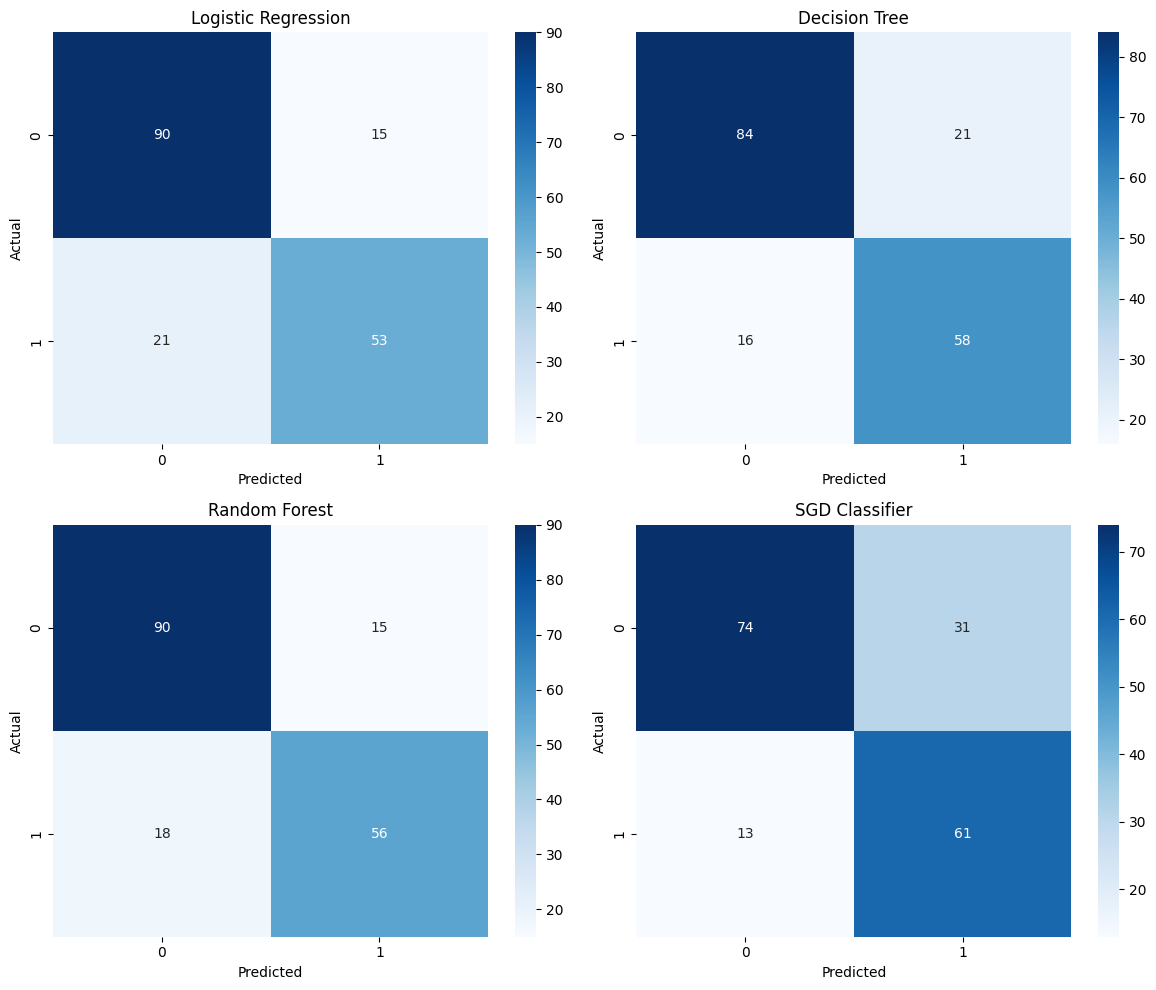

In [45]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

models = {
    "Logistic Regression": y_pred_log,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "SGD Classifier": y_pred_sgd
}

for i, (name, y_pred) in enumerate(models.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'{name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()